In [5]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from HPC_2P_analysis.utils.config import (
    get_one_index,
    get_data_track_type,
    get_data_behavior_type,
)

from HPC_2P_analysis.utils.loadData import (
    load_raw_data,
    load_screen_data,
)


# =============================================================================
# Data loading for plotting
# =============================================================================

def load_plot_data(
    file_path: str | Path,
    *,
    screen_mode: str = "masked",
) -> dict:
    """
    Load data for plotting.

    Rules
    -----
    .mat:
        load raw data by load_raw_data().

    .pkl / .pickle:
        load screen result by load_screen_data().

    For screen pkl
    --------------
    screen_mode="masked":
        use result["masked_attracted_data"].

    screen_mode="raw" or "original":
        use result["attracted_data"].

    Notes
    -----
    This function only loads data for visualization.
    It does not inspect or modify index.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix == ".mat":
        return load_raw_data(file_path)

    if suffix in {".pkl", ".pickle"}:
        return load_screen_data(
            file_path,
            screen_mode=screen_mode,
        )

    raise ValueError(
        f"Unsupported file suffix: {suffix}. "
        "Expected .mat, .pkl, or .pickle."
    )


# =============================================================================
# Plot helpers
# =============================================================================

def _make_original_cmap():
    """
    Original heatmap color.
    """
    palette = ["#351988", "#048498", "#f9f662"]

    return LinearSegmentedColormap.from_list(
        "custom_blue_yellow",
        palette,
        N=256,
    )


def _draw_zones(
    ax,
    zones,
    *,
    x_scale: float = 2.0,
    color="red",
    lw=1.5,
):
    """
    Draw zone boundaries after x-axis scaling.
    """
    if zones is None:
        return

    for zone in zones:
        arr = np.asarray(zone).ravel()

        if len(arr) == 0:
            continue

        if len(arr) == 1:
            ax.axvline(
                float(arr[0]) * x_scale,
                color=color,
                lw=lw,
            )

        else:
            ax.axvline(
                float(arr[0]) * x_scale,
                color=color,
                lw=lw,
            )
            ax.axvline(
                float(arr[1]) * x_scale,
                color=color,
                lw=lw,
            )


def _row_zscore(
    mat: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Row-wise z-score.

    Input
    -----
    mat:
        shape = (n_neuron, n_position)
    """
    mat = np.asarray(mat, dtype=float)

    mu = np.nanmean(
        mat,
        axis=1,
        keepdims=True,
    )

    sd = np.nanstd(
        mat,
        axis=1,
        keepdims=True,
    )

    return (mat - mu) / (sd + eps)


def _get_display_limits(
    mats: list[np.ndarray],
    *,
    display_mode: str,
    vmin=None,
    vmax=None,
    percentile=(1, 99),
):
    """
    Decide color scale.
    """
    if vmin is not None and vmax is not None:
        return vmin, vmax

    valid_values = []

    for mat in mats:
        values = np.asarray(mat).ravel()
        values = values[np.isfinite(values)]

        if len(values) > 0:
            valid_values.append(values)

    if len(valid_values) == 0:
        return None, None

    x = np.concatenate(valid_values)

    if display_mode == "row_zscore":
        default_vmin = -2.0
        default_vmax = 2.0

    else:
        default_vmin, default_vmax = np.nanpercentile(
            x,
            percentile,
        )

    if vmin is None:
        vmin = default_vmin

    if vmax is None:
        vmax = default_vmax

    return vmin, vmax


def _set_scaled_xticks(
    ax,
    *,
    x_max: float,
    n_ticks: int = 5,
):
    """
    Set x ticks from 0 to x_max.
    """
    ticks = np.linspace(
        0,
        x_max,
        n_ticks,
    )

    labels = [
        f"{int(t)}"
        for t in ticks
    ]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_xlim(0, x_max)


def _format_limit_value(x):
    """
    Safely format color limit.
    """
    if x is None:
        return "None"

    return f"{x:.4g}"


# =============================================================================
# Main function
# =============================================================================

def plot_neuron_sorted_heatmaps(
    file_path: str | Path,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str],
    *,
    screen_mode: str = "masked",
    sort_by: tuple[str, str] | None = None,
    display_mode: str = "raw",
    vmin=None,
    vmax=None,
    percentile=(1, 99),
    x_tick_scale: float = 2.0,
    n_xticks: int = 4,
    show_y_ticks: bool = True,
    figsize_per_panel=(4.2, 7.0),
    title_fontsize: int = 24,
    xtick_fontsize: int = 18,
    ytick_fontsize: int = 18,
):
    """
    Plot neuron-sorted heatmaps.

    Data source
    -----------
    If file_path is screen pkl:
        sorting and plotting both use load_screen_data(file_path, screen_mode).

    Therefore:
        screen_mode="masked" uses screened neurons;
        screen_mode="raw" / "original" uses original neurons saved in screen pkl.

    Responsibility
    --------------
    This function only visualizes firing data.

    It does not:
        - inspect trial index;
        - validate firing-index consistency;
        - modify data structure;
        - infer metadata outside file_info.

    Parameters
    ----------
    file_path:
        Original neuro_type*.mat or screen pkl.

    ana_tt:
        Track types to plot.

    ana_bt:
        Behavior types to plot.

    screen_mode:
        {"masked", "screened", "raw", "original"}

        Only used when file_path is a screen pkl.

    sort_by:
        Condition used for sorting neurons.
        If None, use the first plotted condition.

    display_mode:
        {"raw", "row_zscore"}

    x_tick_scale:
        Display x tick labels as position_index * x_tick_scale.
    """
    file_path = Path(file_path)

    data = load_plot_data(
        file_path,
        screen_mode=screen_mode,
    )

    track_type = get_data_track_type(data)
    behavior_type = get_data_behavior_type(data)

    condition_list = [
        (tt, bt)
        for tt in ana_tt
        for bt in ana_bt
    ]

    if len(condition_list) == 0:
        raise ValueError("No conditions provided.")

    mean_mats = {}

    for rule_name, behavior_name in condition_list:
        tt_id, bt_id = get_one_index(
            data,
            rule_name,
            behavior_name,
        )

        fr = data["firing"][tt_id, bt_id]

        if fr is None:
            raise ValueError(
                f"Firing is None for condition: "
                f"{rule_name}, {behavior_name}"
            )

        fr = np.asarray(fr)

        if fr.ndim != 3:
            raise ValueError(
                f"Expected firing to be 3D "
                f"(n_neuron, n_trial, n_position), "
                f"got shape {fr.shape} for condition: "
                f"{rule_name}, {behavior_name}"
            )

        if fr.shape[1] == 0:
            raise ValueError(
                f"No valid trials for condition: "
                f"{rule_name}, {behavior_name}"
            )

        fr_mean = np.nanmean(
            fr,
            axis=1,
        )

        mean_mats[(rule_name, behavior_name)] = fr_mean

    if sort_by is None:
        sort_by = condition_list[0]

    if sort_by not in mean_mats:
        raise ValueError(
            f"sort_by={sort_by} is not in plotted conditions: "
            f"{condition_list}"
        )

    sort_mat = mean_mats[sort_by]

    if sort_mat.ndim != 2:
        raise ValueError(
            f"sort_mat should be 2D "
            f"(n_neuron, n_position), got shape {sort_mat.shape}"
        )

    peak_pos = np.nanargmax(
        sort_mat,
        axis=1,
    )

    peak_val = np.nanmax(
        sort_mat,
        axis=1,
    )

    sort_order = np.lexsort(
        (peak_val, peak_pos)
    )

    plot_mats = {}

    for cond, mat in mean_mats.items():
        if display_mode == "raw":
            plot_mat = mat.copy()

        elif display_mode == "row_zscore":
            plot_mat = _row_zscore(mat)

        else:
            raise ValueError(
                "display_mode must be 'raw' or 'row_zscore'."
            )

        plot_mats[cond] = plot_mat

    vmin, vmax = _get_display_limits(
        list(plot_mats.values()),
        display_mode=display_mode,
        vmin=vmin,
        vmax=vmax,
        percentile=percentile,
    )

    n_neuron, n_position = sort_mat.shape
    x_max = n_position * x_tick_scale

    zones = data.get("zones", None)
    file_info = data.get("file_info", {})

    print("=" * 80)
    print("Neuron sorted heatmap")
    print(f"file_path       : {file_path}")
    print(f"screen_mode     : {screen_mode}")
    print(f"display_mode    : {display_mode}")
    print(f"sort_by         : {sort_by}")
    print(f"n_neuron        : {n_neuron}")
    print(f"n_position      : {n_position}")
    print(f"x_tick_scale    : {x_tick_scale}")
    print(f"x_range         : 0 - {x_max}")
    print(
        "vmin, vmax      : "
        f"{_format_limit_value(vmin)}, {_format_limit_value(vmax)}"
    )

    if len(file_info) > 0:
        print(f"mouse_id        : {file_info.get('mouse_id', 'NA')}")
        print(f"task_type       : {file_info.get('task_type', 'NA')}")
        print(f"reward_mode     : {file_info.get('reward_mode', 'NA')}")
        print(f"track_type_id   : {file_info.get('track_type_id', 'NA')}")
        print(f"behavior_type_id: {file_info.get('behavior_type_id', 'NA')}")

    print(f"track_type      : {track_type}")
    print(f"behavior_type   : {behavior_type}")

    print("conditions:")
    for cond in condition_list:
        mat = mean_mats[cond]
        print(
            f"  {cond[0]} | {cond[1]} | "
            f"shape={mat.shape}"
        )

    print(f"zones           : {zones}")
    print("=" * 80)

    n_panels = len(condition_list)

    fig = plt.figure(
        figsize=(
            figsize_per_panel[0] * n_panels + 0.45,
            figsize_per_panel[1],
        ),
        constrained_layout=True,
    )

    gs = fig.add_gridspec(
        1,
        n_panels + 1,
        width_ratios=[1] * n_panels + [0.045],
        wspace=0.06,
    )

    axes = [
        fig.add_subplot(gs[0, i])
        for i in range(n_panels)
    ]

    cax = fig.add_subplot(gs[0, -1])
    cmap = _make_original_cmap()

    sorted_mats = {}
    im = None

    for ax, cond in zip(axes, condition_list):
        rule_name, behavior_name = cond

        mat = plot_mats[cond][sort_order, :]
        sorted_mats[cond] = mat

        im = ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=(0, x_max, n_neuron, 0),
        )

        _draw_zones(
            ax,
            zones,
            x_scale=x_tick_scale,
        )

        ax.set_title(
            rule_name,
            fontsize=title_fontsize,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        _set_scaled_xticks(
            ax,
            x_max=x_max,
            n_ticks=n_xticks,
        )

        if show_y_ticks:
            ax.tick_params(
                axis="y",
                labelsize=ytick_fontsize,
            )
        else:
            ax.set_yticks([])

        ax.tick_params(
            axis="x",
            labelsize=xtick_fontsize,
        )

    cbar = fig.colorbar(
        im,
        cax=cax,
    )

    cbar.ax.tick_params(labelsize=xtick_fontsize)
    cbar.set_label(
        display_mode,
        fontsize=xtick_fontsize,
    )

    plt.show()

    return {
        "data": data,
        "mean_mats": mean_mats,
        "plot_mats": plot_mats,
        "sorted_mats": sorted_mats,
        "sort_order": sort_order,
        "sort_by": sort_by,
        "condition_list": condition_list,
        "figure": fig,
        "axes": axes,
        "colorbar": cbar,
    }

In [6]:
track_type_1 = ("couple_ACB", "couple_BCA", "CAB", "CBA", "ACB", "BCA", "ABC", "BAC")
track_type_2 = ("CAB", "CBA", "ACB", "BCA", "ABC", "BAC")

In [7]:
file_path = "../../../data/HPC_2p/screen/HP28/HP28_2025-10-19_pattern_screen.pkl"

Neuron sorted heatmap
file_path       : ../../../data/HPC_2p/screen/HP28/HP28_2025-10-19_pattern_screen.pkl
screen_mode     : raw
display_mode    : raw
sort_by         : ('CAB', 'Correct')
n_neuron        : 1099
n_position      : 160
x_tick_scale    : 2.0
x_range         : 0 - 320.0
vmin, vmax      : 0, 1
mouse_id        : HP28
task_type       : pattern
reward_mode     : full
track_type_id   : 0
behavior_type_id: 0
track_type      : ['CAB', 'CBA', 'ACB', 'BCA', 'ABC', 'BAC']
behavior_type   : ['Correct', 'FalseAlarm', 'Miss']
conditions:
  CAB | Correct | shape=(1099, 160)
  CBA | Correct | shape=(1099, 160)
  ACB | Correct | shape=(1099, 160)
  BCA | Correct | shape=(1099, 160)
  ABC | Correct | shape=(1099, 160)
  BAC | Correct | shape=(1099, 160)
zones           : [[ 18.2  30.2]
 [ 48.2  60.2]
 [ 78.2  90.2]
 [108.2 120.2]
 [138.2 150.2]]


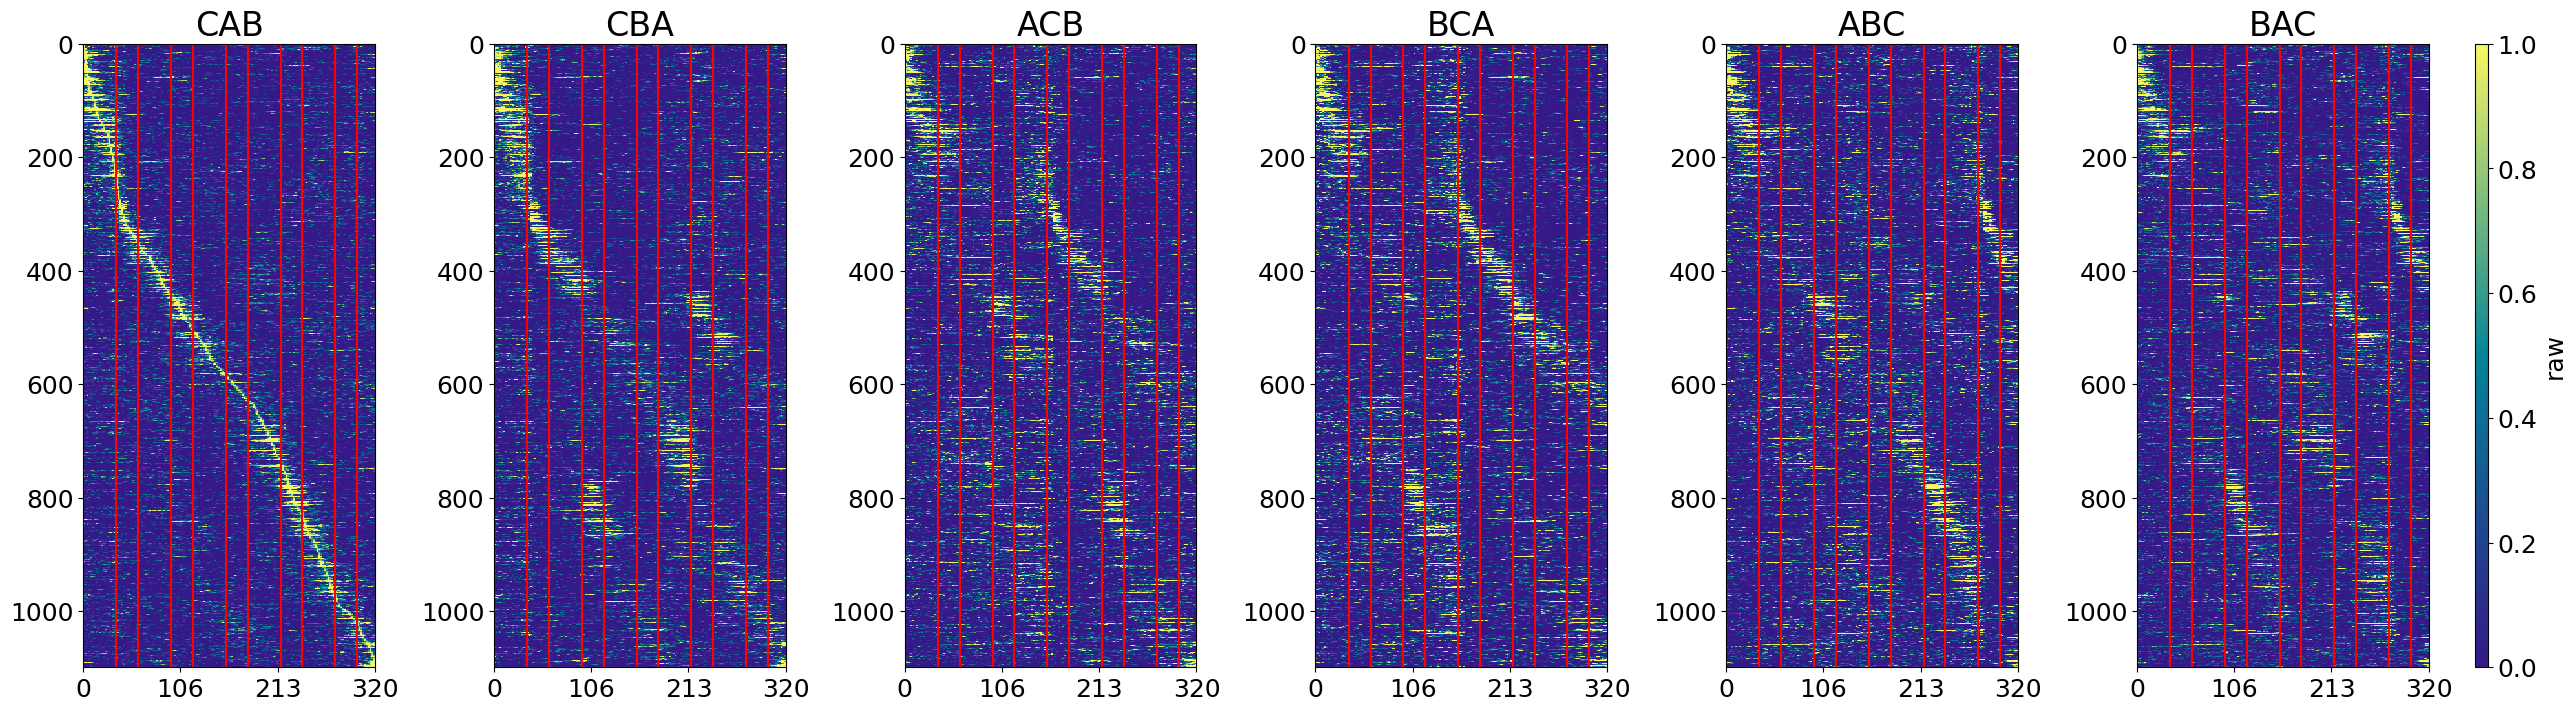

In [11]:
out = plot_neuron_sorted_heatmaps(
    file_path=file_path,
    ana_tt=track_type_2,
    ana_bt=["Correct"],
    screen_mode="raw",
    sort_by=("CAB", "Correct"),
    display_mode="raw",
    vmin=0,
    vmax=1,
)

Neuron sorted heatmap
file_path       : ../../../data/HPC_2p/screen/HP28/HP28_2025-10-19_pattern_screen.pkl
screen_mode     : masked
display_mode    : raw
sort_by         : ('CAB', 'Correct')
n_neuron        : 641
n_position      : 160
x_tick_scale    : 2.0
x_range         : 0 - 320.0
vmin, vmax      : 0, 1
mouse_id        : HP28
task_type       : pattern
reward_mode     : full
track_type_id   : 0
behavior_type_id: 0
track_type      : ['CAB', 'CBA', 'ACB', 'BCA', 'ABC', 'BAC']
behavior_type   : ['Correct', 'FalseAlarm', 'Miss']
conditions:
  CAB | Correct | shape=(641, 160)
  CBA | Correct | shape=(641, 160)
  ACB | Correct | shape=(641, 160)
  BCA | Correct | shape=(641, 160)
  ABC | Correct | shape=(641, 160)
  BAC | Correct | shape=(641, 160)
zones           : [[ 18.2  30.2]
 [ 48.2  60.2]
 [ 78.2  90.2]
 [108.2 120.2]
 [138.2 150.2]]


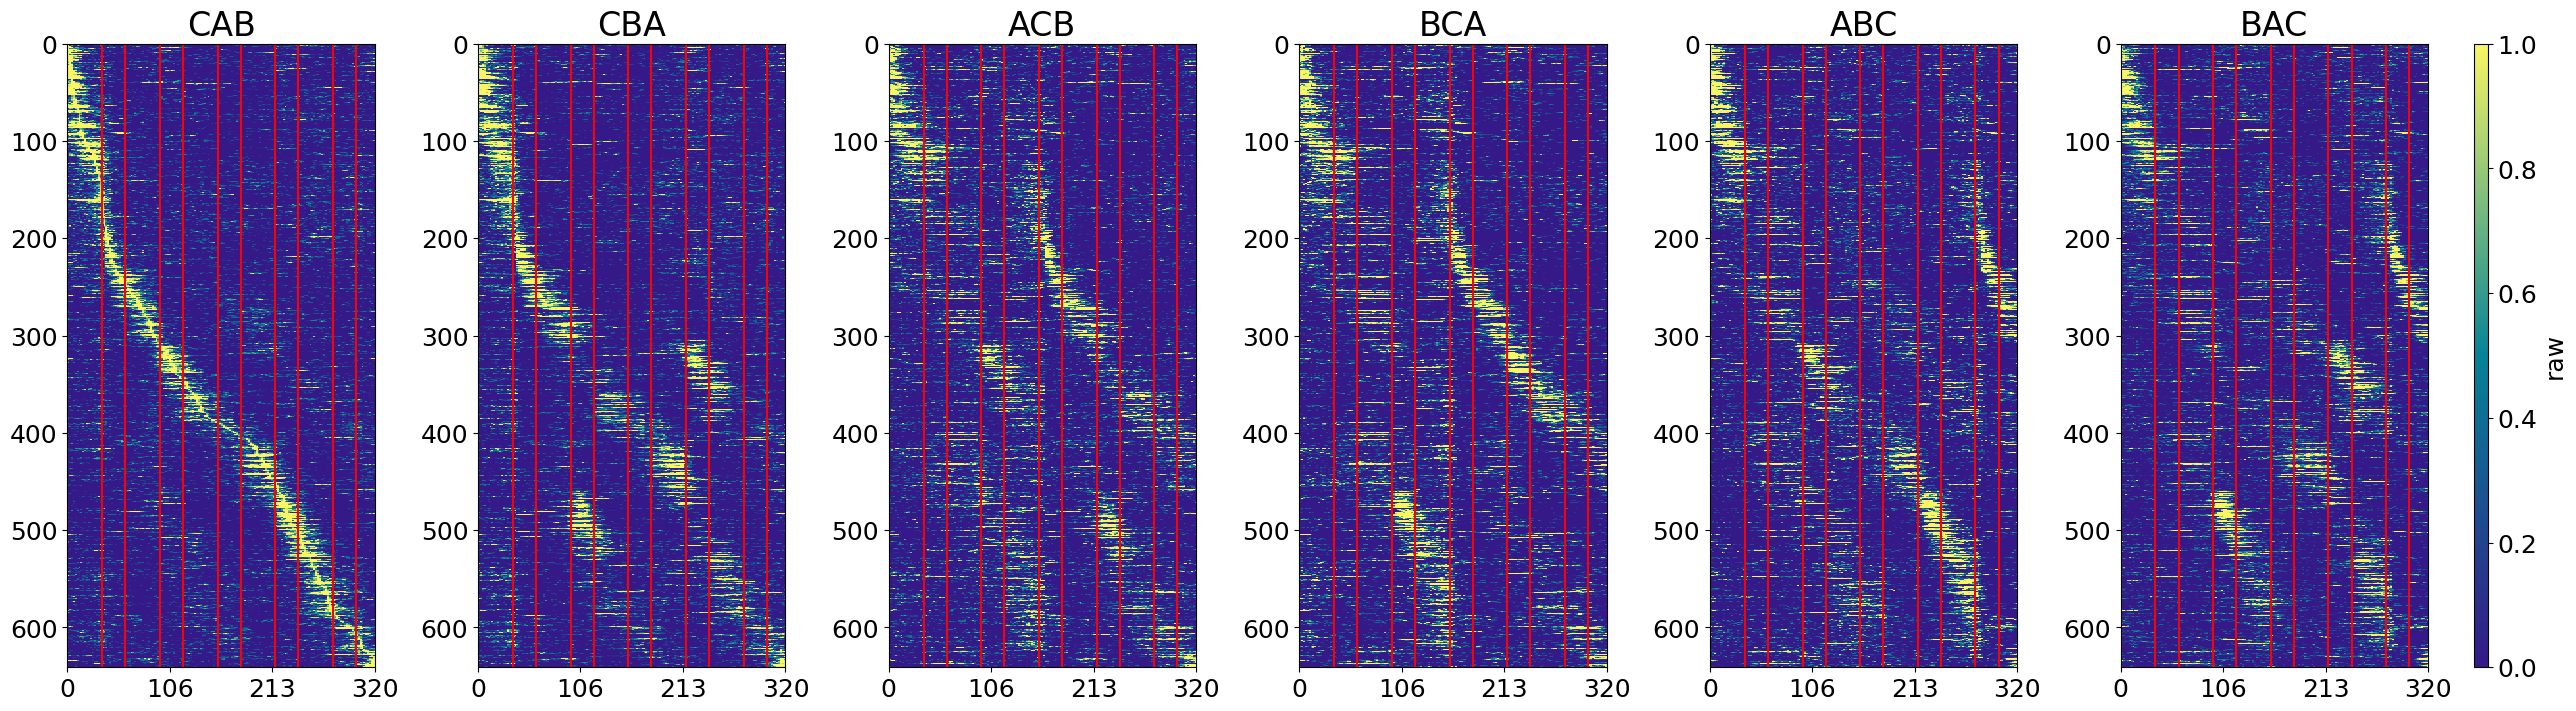

In [9]:
out = plot_neuron_sorted_heatmaps(
    file_path=file_path,
    ana_tt=track_type_2,
    ana_bt=["Correct"],
    screen_mode="masked",
    sort_by=("CAB", "Correct"),
    display_mode="raw",
    vmin=0,
    vmax=1,
)